# DAS510 Take-home Exam Solution

## Problem 1 (50점) — fMRI Data Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_smoothing_spline

data = np.loadtxt("fmri.txt")
time = data[:, 0].astype(int)
fmri = data[:, 1:]

var_names = np.array(["c-frontal", "c-parietal", "s-frontal", "s-parietal"])
print("time:", time)
print("fmri shape:", fmri.shape)

time: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
fmri shape: (19, 4)


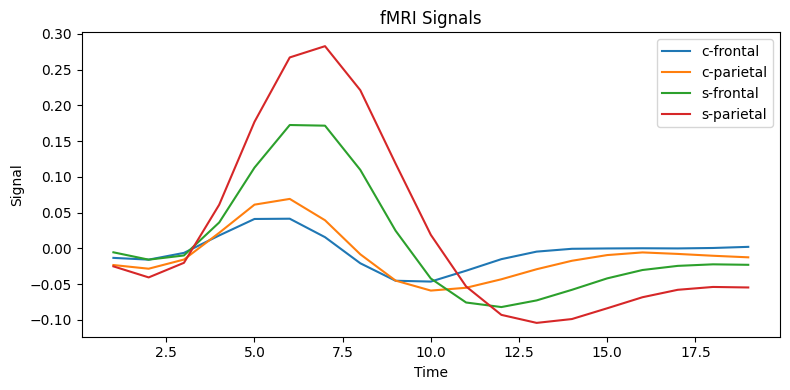

In [2]:
# fMRI 데이터 시각화
plt.figure(figsize=(8, 4))
for j, name in enumerate(var_names):
    plt.plot(time, fmri[:, j], label=name)
plt.xlabel("Time")
plt.ylabel("Signal")
plt.title("fMRI Signals")
plt.legend()
plt.tight_layout()
plt.show()

### (a) 각 fMRI 변수의 평균과 표준편차

In [3]:
means = np.mean(fmri, axis=0)  # (4,)
stds  = np.std(fmri, axis=0)   # (4,)

for name, m, s in zip(var_names, means, stds):
    print(f"{name}: mean = {m:.6f}, std = {s:.6f}")

c-frontal: mean = -0.004080, std = 0.022919
c-parietal: mean = -0.009258, std = 0.034449
s-frontal: mean = 0.006676, std = 0.077035
s-parietal: mean = 0.020821, std = 0.125113


### (b) 각 변수의 신호값이 가장 큰 시간 지점

In [4]:
max_time_idx = np.argmax(fmri, axis=0)  # 각 열(변수)에서 최대 행(시간) 인덱스

for name, idx in zip(var_names, max_time_idx):
    print(f"{name}: time = {time[idx]}")

c-frontal: time = 6
c-parietal: time = 6
s-frontal: time = 6
s-parietal: time = 7


### (c) 각 시간 지점에서 신호값이 가장 큰 변수

In [5]:
max_var_idx   = np.argmax(fmri, axis=1)  # 각 행(시간)에서 최대 열(변수) 인덱스
max_var_names = var_names[max_var_idx]   # fancy indexing으로 변수 이름 추출

for t, name in zip(time, max_var_names):
    print(f"time {t:2d}: {name}")

time  1: s-frontal
time  2: c-frontal
time  3: c-frontal
time  4: s-parietal
time  5: s-parietal
time  6: s-parietal
time  7: s-parietal
time  8: s-parietal
time  9: s-parietal
time 10: s-parietal
time 11: c-frontal
time 12: c-frontal
time 13: c-frontal
time 14: c-frontal
time 15: c-frontal
time 16: c-frontal
time 17: c-frontal
time 18: c-frontal
time 19: c-frontal


### (d) 신호값이 0.1을 초과하는 변수가 하나라도 있는 시간 지점

In [6]:
mask = np.any(fmri > 0.1, axis=1)  # 각 행에서 하나라도 True이면 True
print("time points:", time[mask])

time points: [5 6 7 8 9]


### (e) 각 변수에서 신호값이 가장 작은 두 개의 시간 지점

In [7]:
sorted_idx  = np.argsort(fmri, axis=0)  # 각 열을 오름차순으로 정렬한 인덱스
bottom2_idx = sorted_idx[:2, :]         # 상위 2개 (가장 작은 값) 인덱스

for j, name in enumerate(var_names):
    times = time[bottom2_idx[:, j]]     # fancy indexing
    print(f"{name}: time = {times}")

c-frontal: time = [10  9]
c-parietal: time = [10 11]
s-frontal: time = [12 11]
s-parietal: time = [13 14]


### (f) 각 시간 지점에서 각 변수값과 모든 fMRI 변수들의 평균값 간의 절대 차이

In [8]:
row_means = np.mean(fmri, axis=1)              # (19,) — 각 시간의 전체 변수 평균
abs_diff  = np.abs(fmri - row_means[:, np.newaxis])  # (19,4) broadcasting

print("abs_diff shape:", abs_diff.shape)
print(abs_diff)

abs_diff shape: (19, 4)
[[0.00352493 0.006504   0.01131241 0.00833334]
 [0.00938956 0.00329554 0.00936387 0.01545789]
 [0.00669561 0.00261019 0.00310344 0.00718886]
 [0.01621397 0.01250937 0.0019457  0.02677764]
 [0.05691559 0.03689223 0.01487133 0.07893649]
 [0.09608562 0.06838754 0.03497785 0.12949531]
 [0.11169875 0.08802986 0.04426626 0.15546235]
 [0.09633194 0.08376458 0.03433643 0.14576009]
 [0.05854726 0.05833342 0.01149317 0.10538752]
 [0.01425146 0.02684689 0.01000341 0.05110176]
 [0.02258638 0.00127228 0.0218741  0.00056001]
 [0.04327227 0.01512238 0.02373762 0.03465703]
 [0.04813747 0.02351277 0.02010417 0.05154607]
 [0.04309144 0.02635321 0.01428014 0.05516451]
 [0.03369632 0.02443528 0.00815016 0.04998144]
 [0.02618229 0.02036904 0.00423754 0.04231378]
 [0.02248896 0.01480776 0.00191621 0.03538051]
 [0.02206454 0.01118741 0.00080618 0.03244577]
 [0.02414358 0.0095009  0.00097377 0.03267072]]


### (g) c-frontal과 c-parietal 간의 상관계수

In [9]:
corr_matrix = np.corrcoef(fmri[:, 0], fmri[:, 1])  # (2,2) 상관행렬
print(f"correlation coefficient (c-frontal vs c-parietal) = {corr_matrix[0, 1]:.6f}")

correlation coefficient (c-frontal vs c-parietal) = 0.928970


### (h) s-frontal 스무딩 스플라인 보간 및 시각화

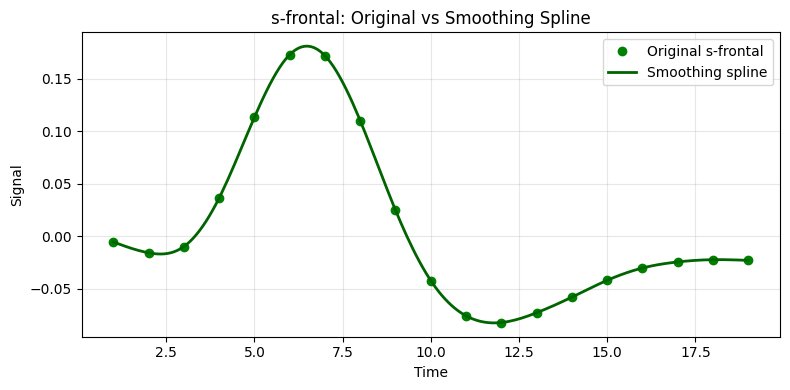

In [10]:
s_frontal = fmri[:, 2]                                     # s-frontal 신호
spline    = make_smoothing_spline(time.astype(float), s_frontal)  # 스무딩 스플라인 적합
time_fine = np.linspace(time[0], time[-1], 200)            # 촘촘한 시간 격자
spline_vals = spline(time_fine)

plt.figure(figsize=(8, 4))
plt.plot(time, s_frontal, 'o', color='green', label='Original s-frontal', markersize=6)
plt.plot(time_fine, spline_vals, '-', color='darkgreen', linewidth=2, label='Smoothing spline')
plt.xlabel("Time")
plt.ylabel("Signal")
plt.title("s-frontal: Original vs Smoothing Spline")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Problem 2 (50점) — Gradient Descent for Poisson Regression (HIV Data)

In [11]:
import numpy as np

quarter = np.arange(14) + 1
deaths  = np.array([0, 1, 2, 3, 1, 4, 9, 18, 23, 31, 20, 25, 37, 45])

x = quarter
y = deaths

### (a) NumPy로 Gradient Descent 직접 구현

모형: $Y_i \sim \text{Poisson}(\mu(X_i))$, $\mu(X_i) = e^{\theta_1 + \theta_2 X_i}$

음의 로그 가능도:
$$L(\theta_1,\theta_2) = \sum_{i=1}^n \left(e^{\theta_1+\theta_2 x_i} - (\theta_1+\theta_2 x_i)y_i\right)$$

Gradient:
$$\nabla L = \left(\sum e^{\theta_1+\theta_2 x_i} - y_i,\; \sum x_i e^{\theta_1+\theta_2 x_i} - x_i y_i\right)^\top$$

In [12]:
def neg_loglike(theta1, theta2, x, y):
    """Negative log-likelihood of Poisson model (without log(y!) constant)."""
    linear = theta1 + theta2 * x
    return np.sum(np.exp(linear) - linear * y)

def grad_neg_loglike(theta1, theta2, x, y):
    """Gradient of negative log-likelihood."""
    linear   = theta1 + theta2 * x
    exp_term = np.exp(linear)
    g1 = np.sum(exp_term - y)
    g2 = np.sum(x * exp_term - x * y)
    return np.array([g1, g2])

In [13]:
# Hyperparameters
lr       = 0.0001
max_iter = 10000
tol      = 1e-10

# Initial values
theta1 = 0.0
theta2 = 0.0

prev_loss      = neg_loglike(theta1, theta2, x, y)
converged_iter = max_iter

for i in range(max_iter):
    grad       = grad_neg_loglike(theta1, theta2, x, y)
    theta1_new = theta1 - lr * grad[0]
    theta2_new = theta2 - lr * grad[1]
    new_loss   = neg_loglike(theta1_new, theta2_new, x, y)

    # 수렴 조건: NLL 변화량 < tolerance
    if abs(new_loss - prev_loss) < tol:
        theta1, theta2 = theta1_new, theta2_new
        converged_iter = i + 1
        break

    theta1, theta2 = theta1_new, theta2_new
    prev_loss = new_loss

print(f"Converged at iteration : {converged_iter}")
print(f"theta1 = {theta1:.6f}")
print(f"theta2 = {theta2:.6f}")
print(f"Final NLL = {neg_loglike(theta1, theta2, x, y):.6f}")

Converged at iteration : 10000
theta1 = 0.482080
theta2 = 0.221188
Final NLL = -464.921920


### (b) PyTorch로 Gradient Descent 구현

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cpu")

# 데이터 텐서 변환
x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)  # (14, 1)
y_t = torch.tensor(y, dtype=torch.float32).to(device)               # (14,)

In [15]:
# log mu(x) = theta1 + theta2 * x 를 표현하는 선형 모형
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1, bias=True)
        nn.init.zeros_(self.linear.weight)  # theta2 초기값 = 0
        nn.init.zeros_(self.linear.bias)    # theta1 초기값 = 0

    def forward(self, x):
        return self.linear(x).squeeze(1)    # (N,1) -> (N,)

linear_model = LinearModel().to(device)

In [16]:
# 손실 함수: Poisson NLL (log_input=True → 입력이 log_mu)
loss_fn   = nn.PoissonNLLLoss(log_input=True, reduction='sum')
optimizer = optim.SGD(linear_model.parameters(), lr=lr)

prev_loss_pt      = None
converged_iter_pt = max_iter

for i in range(max_iter):
    optimizer.zero_grad()
    log_mu = linear_model(x_t)          # log mu = theta1 + theta2 * x
    loss   = loss_fn(log_mu, y_t)       # Poisson NLL

    # 수렴 조건
    if prev_loss_pt is not None and abs(loss.item() - prev_loss_pt) < tol:
        converged_iter_pt = i
        break

    prev_loss_pt = loss.item()
    loss.backward()
    optimizer.step()

theta2_pt = linear_model.linear.weight.item()  # 기울기 = theta2
theta1_pt = linear_model.linear.bias.item()    # 절편   = theta1

print(f"Converged at iteration : {converged_iter_pt}")
print(f"theta1 = {theta1_pt:.6f}")
print(f"theta2 = {theta2_pt:.6f}")
print(f"Final NLL = {loss.item():.6f}")

Converged at iteration : 9098
theta1 = 0.480444
theta2 = 0.244365
Final NLL = -471.901001


In [17]:
# 결과 비교
print("--- 결과 비교 ---")
print(f"NumPy   : theta1={theta1:.6f}, theta2={theta2:.6f}")
print(f"PyTorch : theta1={theta1_pt:.6f}, theta2={theta2_pt:.6f}")
print(f"Newton's method (참고): theta1≈0.3396, theta2≈0.2565")

--- 결과 비교 ---
NumPy   : theta1=0.482080, theta2=0.221188
PyTorch : theta1=0.480444, theta2=0.244365
Newton's method (참고): theta1≈0.3396, theta2≈0.2565
